# 🌿 Planet: Understanding the Amazon from Space
### Tracking the Human Footprint in the Amazon Rainforest with Machine Learning
---
> **Objective:** Use multi-spectral satellite imagery to classify land-use and
> atmospheric conditions in the Amazon basin. Labels predict human disturbance
> (agriculture, roads, mining, logging) alongside natural and weather states.

**Dataset:** Inspired by the Kaggle *Planet: Understanding the Amazon from Space* competition.  
**Task:** Multi-label image classification (each chip may carry several tags simultaneously).


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Table of Contents
1. [Environment Setup](#1-environment-setup)
2. [Data Loading & EDA](#2-data-loading--eda)
3. [Image Visualisation](#3-image-visualisation)
4. [Feature Engineering](#4-feature-engineering)
5. [Multi-Label Binarisation](#5-multi-label-binarisation)
6. [Baseline: Random Forest](#6-baseline-random-forest)
7. [Gradient Boosting Model](#7-gradient-boosting-model)
8. [Model Evaluation & Metrics](#8-model-evaluation--metrics)
9. [Prediction on Test Set](#9-prediction-on-test-set)
10. [Submission File](#10-submission-file)
11. [Visualise Predictions](#11-visualise-predictions)
12. [Conclusions & Next Steps](#12-conclusions--next-steps)


## 1 · Environment Setup

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from PIL import Image
import os, glob, warnings, json, zipfile
from collections import Counter

from sklearn.multioutput import MultiOutputClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (f1_score, classification_report,
                              hamming_loss, accuracy_score)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
np.random.seed(42)

print("Libraries loaded ✓")
print(f"NumPy  {np.__version__}  |  Pandas {pd.__version__}")


Libraries loaded ✓
NumPy  2.0.2  |  Pandas 2.2.2


## 2 · Data Loading & Exploratory Data Analysis

In [5]:
DATA_DIR   = "/content/drive/MyDrive/Colab Notebooks/files/data"
TRAIN_CSV  = os.path.join(DATA_DIR, "/content/drive/MyDrive/Colab Notebooks/files/data/train.csv")
FEAT_CSV   = os.path.join(DATA_DIR, "/content/drive/MyDrive/Colab Notebooks/files/data/train_features.csv")
SUBM_CSV   = os.path.join(DATA_DIR, "/content/drive/MyDrive/Colab Notebooks/files/data/sample_submission.csv")
TRAIN_JPG  = os.path.join(DATA_DIR, "/content/drive/MyDrive/Colab Notebooks/files/data/train-jpg")
TEST_JPG   = os.path.join(DATA_DIR, "/content/drive/MyDrive/Colab Notebooks/files/data/test-jpg")

train_df = pd.read_csv(TRAIN_CSV)
feat_df  = pd.read_csv(FEAT_CSV)
subm_df  = pd.read_csv(SUBM_CSV)

print(f"Train samples : {len(train_df):,}")
print(f"Test  samples : {len(subm_df):,}")
print(f"Feature cols  : {feat_df.shape[1]}")
train_df.head()


Train samples : 600
Test  samples : 150
Feature cols  : 16


,image_name,tags
0,train_00000,clear
1,train_00001,cloudy agriculture
2,train_00002,clear primary bare_ground habitation
3,train_00003,clear habitation
4,train_00004,haze water


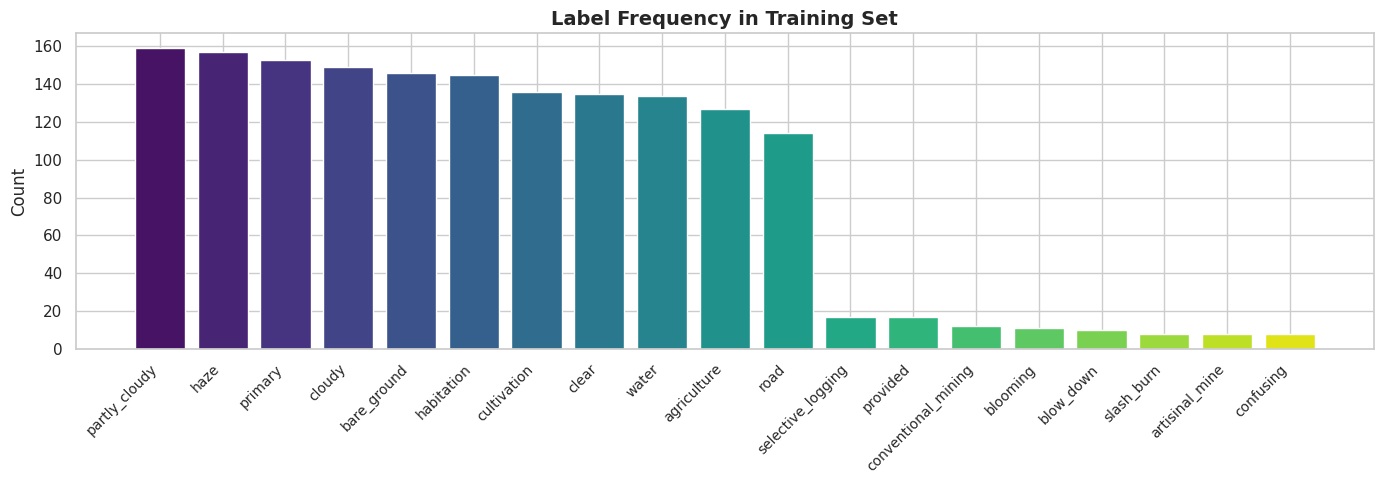

Most common label: partly_cloudy — 159 occurrences


In [6]:
# ── Label distribution ──────────────────────────────────────────
all_labels = []
for tags in train_df["tags"]:
    all_labels.extend(tags.split())

label_counts = Counter(all_labels)
lc_df = pd.DataFrame(label_counts.items(), columns=["label","count"]).sort_values("count", ascending=False)

plt.figure(figsize=(14,5))
colors = sns.color_palette("viridis", len(lc_df))
plt.bar(lc_df["label"], lc_df["count"], color=colors)
plt.xticks(rotation=45, ha="right", fontsize=10)
plt.title("Label Frequency in Training Set", fontsize=14, fontweight="bold")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("label_distribution.png", dpi=120)
plt.show()
print("Most common label:", lc_df.iloc[0]["label"],
      "—", lc_df.iloc[0]["count"], "occurrences")


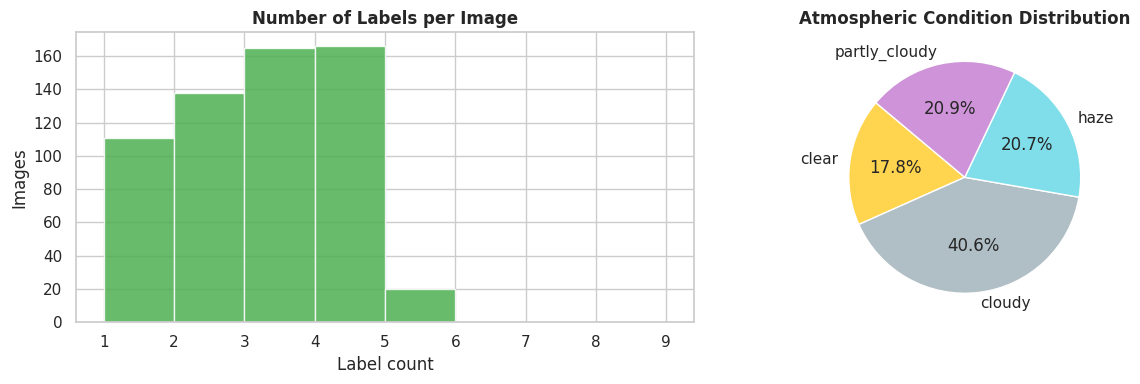

In [7]:
# ── Labels per image ────────────────────────────────────────────
train_df["n_labels"] = train_df["tags"].apply(lambda x: len(x.split()))
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(train_df["n_labels"], bins=range(1,10), edgecolor="white",
             color="#4CAF50", alpha=0.85)
axes[0].set_title("Number of Labels per Image", fontweight="bold")
axes[0].set_xlabel("Label count"); axes[0].set_ylabel("Images")

weather_map = {}
for t in train_df["tags"]:
    for w in ["clear","cloudy","partly_cloudy","haze"]:
        if w in t:
            weather_map[w] = weather_map.get(w,0)+1
axes[1].pie(weather_map.values(), labels=weather_map.keys(), autopct="%1.1f%%",
            colors=["#FFD54F","#B0BEC5","#80DEEA","#CE93D8"], startangle=140)
axes[1].set_title("Atmospheric Condition Distribution", fontweight="bold")
plt.tight_layout()
plt.savefig("label_stats.png", dpi=120)
plt.show()


## 3 · Image Visualisation

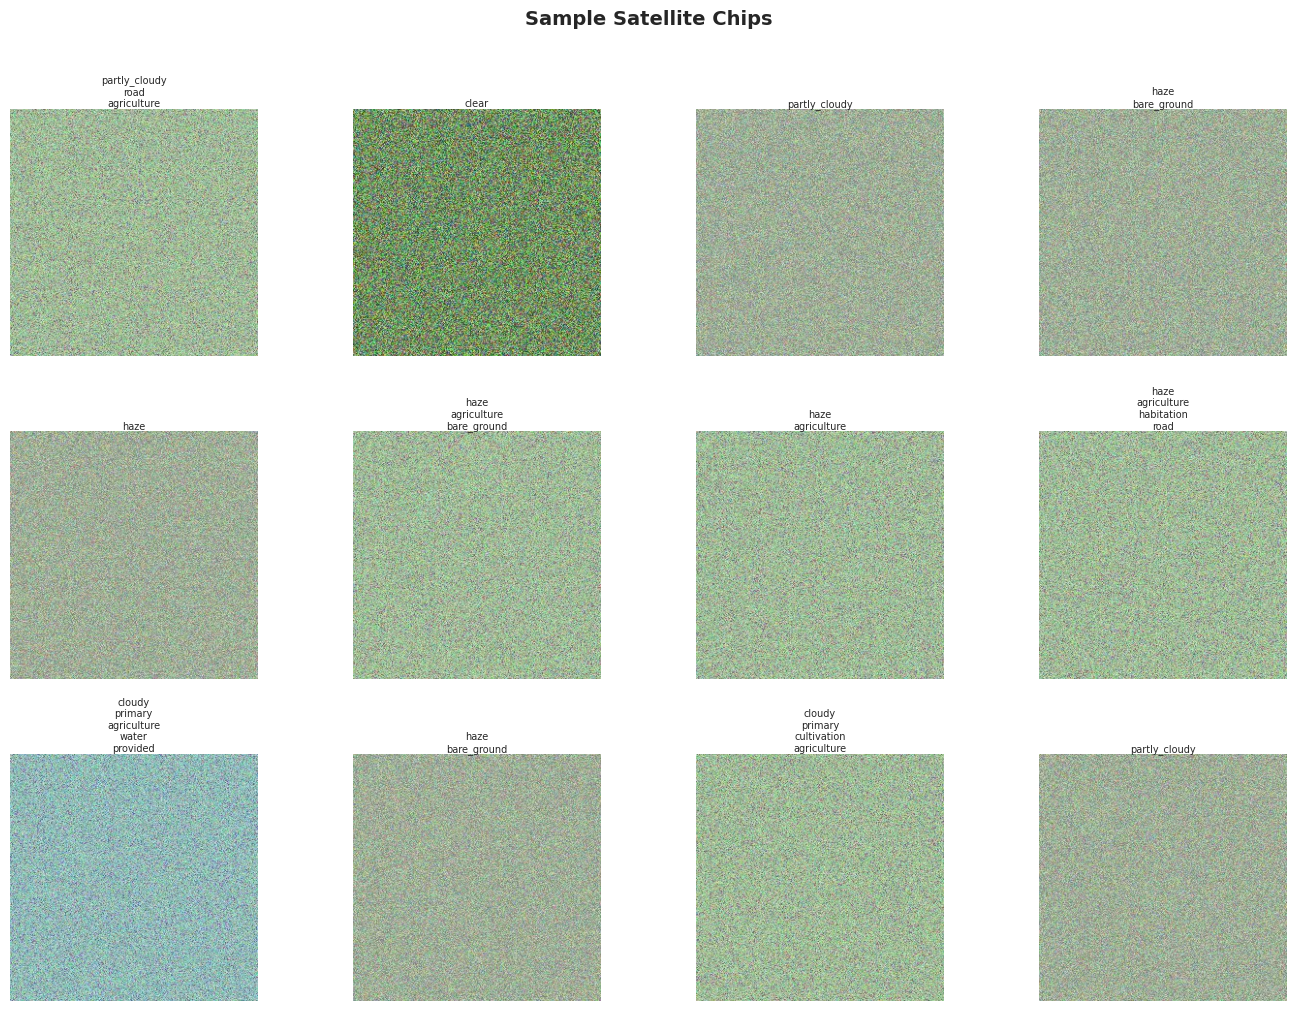

In [8]:
def show_chips(df, n=12, title="Sample Satellite Chips"):
    fig, axes = plt.subplots(3, 4, figsize=(14, 10))
    axes = axes.ravel()
    sample = df.sample(n, random_state=7).reset_index(drop=True)
    for i, row in sample.iterrows():
        path = os.path.join(TRAIN_JPG, row["image_name"]+".jpg")
        img  = np.array(Image.open(path))
        axes[i].imshow(img)
        label_text = "\n".join(row["tags"].split())
        axes[i].set_title(label_text, fontsize=7, pad=2)
        axes[i].axis("off")
    plt.suptitle(title, fontsize=14, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.savefig("sample_chips.png", dpi=120)
    plt.show()

show_chips(train_df)


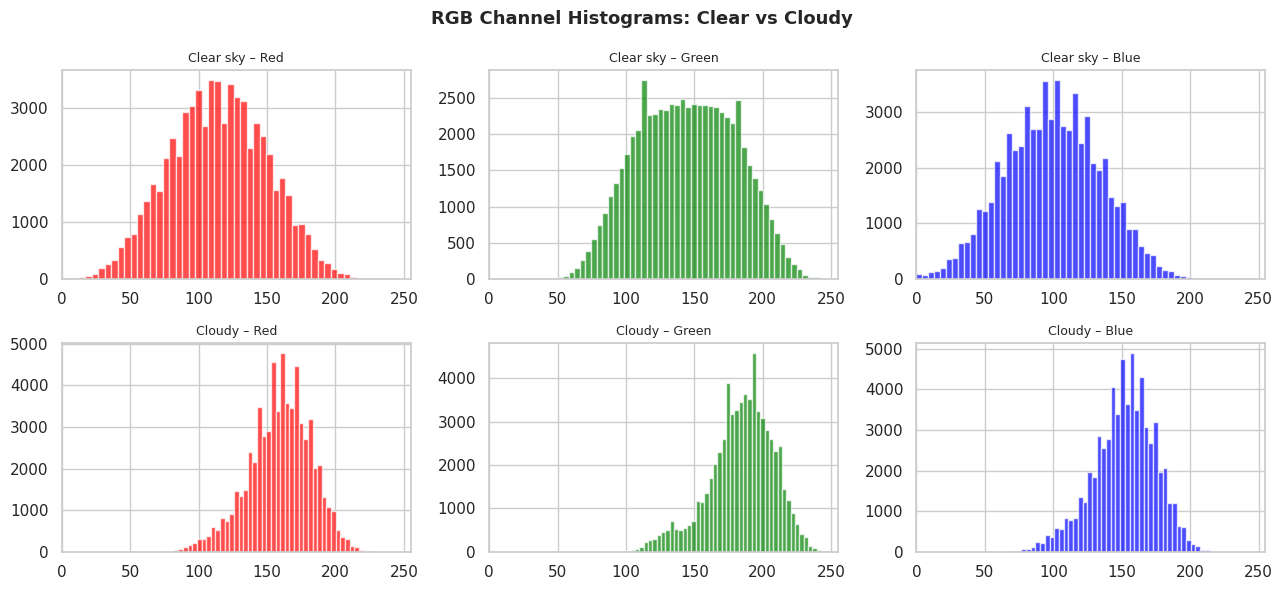

In [9]:
# ── Channel histograms for a clear vs cloudy chip ───────────────
def channel_hist(image_name, label, ax_row, axes):
    path = os.path.join(TRAIN_JPG, image_name+".jpg")
    arr  = np.array(Image.open(path))
    for ci, (ch, col) in enumerate(zip(["Red","Green","Blue"],["red","green","blue"])):
        axes[ax_row][ci].hist(arr[:,:,ci].ravel(), bins=50, color=col, alpha=0.7)
        axes[ax_row][ci].set_title(f"{label} – {ch}", fontsize=9)
        axes[ax_row][ci].set_xlim(0,255)

clear_row  = train_df[train_df["tags"].str.contains("clear")].iloc[0]
cloudy_row = train_df[train_df["tags"].str.contains("cloudy")].iloc[0]

fig, axes = plt.subplots(2, 3, figsize=(13, 6))
channel_hist(clear_row["image_name"],  "Clear sky",  0, axes)
channel_hist(cloudy_row["image_name"], "Cloudy",     1, axes)
plt.suptitle("RGB Channel Histograms: Clear vs Cloudy", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("channel_histograms.png", dpi=120)
plt.show()


## 4 · Feature Engineering

In [10]:
# Band statistics already extracted; let's add ratio features
feat_df["RG_ratio"]  = feat_df["R_mean"] / (feat_df["G_mean"] + 1e-6)
feat_df["RB_ratio"]  = feat_df["R_mean"] / (feat_df["B_mean"] + 1e-6)
feat_df["GB_ratio"]  = feat_df["G_mean"] / (feat_df["B_mean"] + 1e-6)
feat_df["brightness"]= (feat_df["R_mean"] + feat_df["G_mean"] + feat_df["B_mean"]) / 3
feat_df["contrast"]  = (feat_df["R_std"]  + feat_df["G_std"]  + feat_df["B_std"])  / 3

FEATURE_COLS = [c for c in feat_df.columns
                if c not in ("image_name", "tags")]

print(f"Total feature columns: {len(FEATURE_COLS)}")
print(FEATURE_COLS)
feat_df[FEATURE_COLS].describe().T.round(3)


Total feature columns: 19
['R_mean', 'R_std', 'R_min', 'R_max', 'G_mean', 'G_std', 'G_min', 'G_max', 'B_mean', 'B_std', 'B_min', 'B_max', 'ndvi_proxy_mean', 'ndvi_proxy_std', 'RG_ratio', 'RB_ratio', 'GB_ratio', 'brightness', 'contrast']


,count,mean,std,min,25%,50%,75%,max
R_mean,600.0,145.279,20.819,84.326,144.165,159.150,159.282,159.626
R_std,600.0,24.002,6.893,19.584,19.704,19.764,22.883,41.514
R_min,600.0,61.420,34.615,0.000,53.750,75.000,88.000,95.000
R_max,600.0,229.318,9.581,198.000,226.000,231.000,234.000,255.000
G_mean,600.0,169.983,12.765,143.800,174.103,174.248,174.392,184.102
G_std,600.0,24.361,7.444,19.529,19.642,19.698,23.780,44.964
G_min,600.0,88.307,31.591,0.000,88.000,106.000,109.000,115.000
G_max,600.0,244.748,6.140,235.000,240.000,243.000,251.000,255.000
B_mean,600.0,147.865,25.766,99.005,151.663,151.787,151.943,181.960
B_std,600.0,23.695,6.695,19.352,19.493,19.551,22.728,41.002


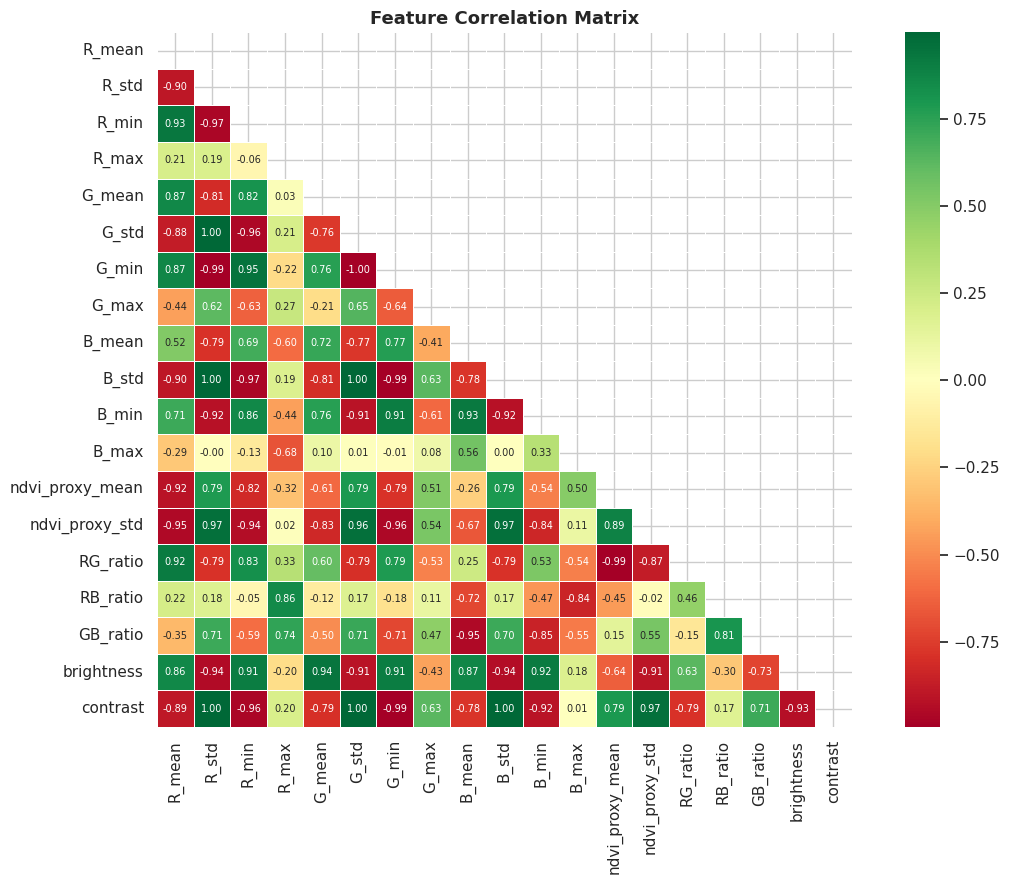

In [11]:
# ── Correlation heatmap ─────────────────────────────────────────
plt.figure(figsize=(12, 9))
corr = feat_df[FEATURE_COLS].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap="RdYlGn", center=0,
            annot=True, fmt=".2f", annot_kws={"size":7},
            linewidths=.4, square=True)
plt.title("Feature Correlation Matrix", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=120)
plt.show()


## 5 · Multi-Label Binarisation

In [12]:
mlb = MultiLabelBinarizer()

tag_lists = [tags.split() for tags in feat_df["tags"]]
Y = mlb.fit_transform(tag_lists)

print(f"Label matrix shape : {Y.shape}")
print(f"Classes ({len(mlb.classes_)}): {list(mlb.classes_)}")

X = feat_df[FEATURE_COLS].values
print(f"Feature matrix     : {X.shape}")


Label matrix shape : (600, 19)
Classes (19): ['agriculture', 'artisinal_mine', 'bare_ground', 'blooming', 'blow_down', 'clear', 'cloudy', 'confusing', 'conventional_mining', 'cultivation', 'habitation', 'haze', 'partly_cloudy', 'primary', 'provided', 'road', 'selective_logging', 'slash_burn', 'water']
Feature matrix     : (600, 19)


In [13]:
X_train, X_val, y_train, y_val = train_test_split(
    X, Y, test_size=0.2, random_state=42)

print(f"Train : {X_train.shape}  |  Val : {X_val.shape}")


Train : (480, 19)  |  Val : (120, 19)


## 6 · Baseline: Random Forest Classifier

In [14]:
rf_base = MultiOutputClassifier(
    RandomForestClassifier(n_estimators=100, max_depth=8,
                           n_jobs=-1, random_state=42))

print("Training Random Forest …")
rf_base.fit(X_train, y_train)
print("Done ✓")

y_pred_rf = rf_base.predict(X_val)

f2_rf = f1_score(y_val, y_pred_rf, average="samples", zero_division=0)
hl_rf = hamming_loss(y_val, y_pred_rf)
print(f"\nRandom Forest Results")
print(f"  Sample F1 score  : {f2_rf:.4f}")
print(f"  Hamming loss     : {hl_rf:.4f}")


Training Random Forest …
Done ✓

Random Forest Results
  Sample F1 score  : 0.3298
  Hamming loss     : 0.1154


## 7 · Gradient Boosting Model

In [15]:
gb_clf = MultiOutputClassifier(
    GradientBoostingClassifier(n_estimators=80, max_depth=4,
                               learning_rate=0.1, random_state=42))

print("Training Gradient Boosting (this may take a moment) …")
gb_clf.fit(X_train, y_train)
print("Done ✓")

y_pred_gb = gb_clf.predict(X_val)

f2_gb = f1_score(y_val, y_pred_gb, average="samples", zero_division=0)
hl_gb = hamming_loss(y_val, y_pred_gb)
print(f"\nGradient Boosting Results")
print(f"  Sample F1 score  : {f2_gb:.4f}")
print(f"  Hamming loss     : {hl_gb:.4f}")


Training Gradient Boosting (this may take a moment) …
Done ✓

Gradient Boosting Results
  Sample F1 score  : 0.3840
  Hamming loss     : 0.1281


## 8 · Model Evaluation & Metrics

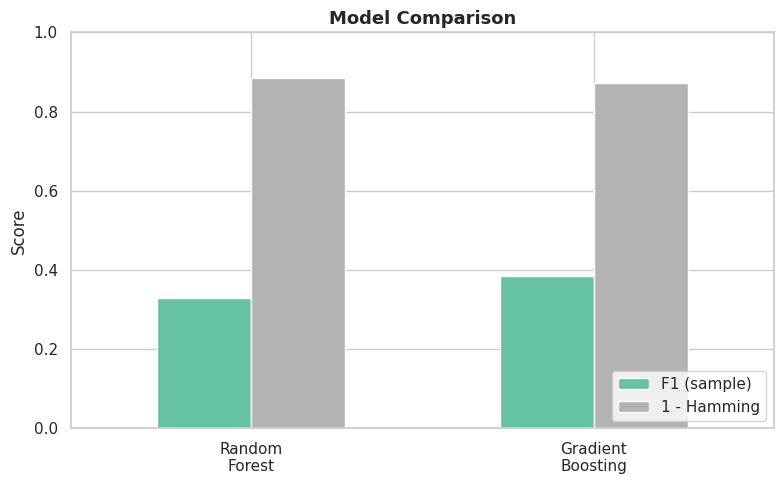

                    F1 (sample)  1 - Hamming
Random\nForest           0.3298       0.8846
Gradient\nBoosting       0.3840       0.8719


In [16]:
# ── Side-by-side bar chart ──────────────────────────────────────
metrics = {
    "Random\nForest":     {"F1 (sample)": f2_rf, "1 - Hamming": 1-hl_rf},
    "Gradient\nBoosting": {"F1 (sample)": f2_gb, "1 - Hamming": 1-hl_gb},
}
df_metrics = pd.DataFrame(metrics).T
df_metrics.plot(kind="bar", figsize=(8,5), colormap="Set2", edgecolor="white",
                width=0.55)
plt.title("Model Comparison", fontsize=13, fontweight="bold")
plt.ylabel("Score"); plt.xticks(rotation=0)
plt.ylim(0,1); plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=120)
plt.show()
print(df_metrics.round(4).to_string())


Best model: Gradient Boosting



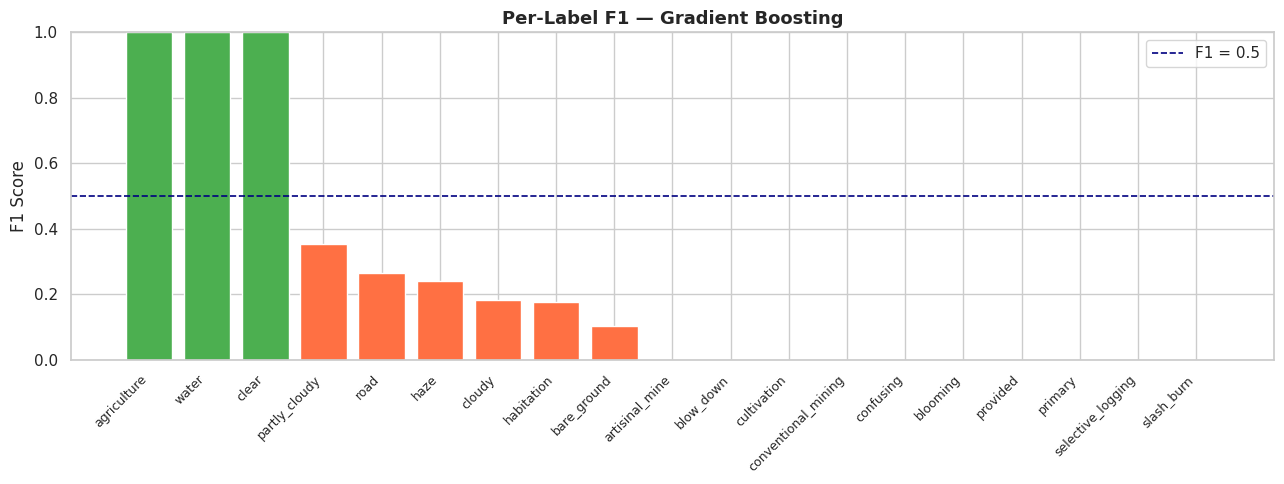

In [17]:
# ── Per-label F1 for best model ─────────────────────────────────
best_pred = y_pred_gb if f2_gb >= f2_rf else y_pred_rf
best_name = "Gradient Boosting" if f2_gb >= f2_rf else "Random Forest"
print(f"Best model: {best_name}\n")

per_label_f1 = f1_score(y_val, best_pred, average=None, zero_division=0)
pl_df = (pd.DataFrame({"label": mlb.classes_, "f1": per_label_f1})
           .sort_values("f1", ascending=False))

plt.figure(figsize=(13,5))
bar_colors = ["#4CAF50" if f>0.5 else "#FF7043" for f in pl_df["f1"]]
plt.bar(pl_df["label"], pl_df["f1"], color=bar_colors)
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.axhline(0.5, color="navy", linestyle="--", linewidth=1.2, label="F1 = 0.5")
plt.title(f"Per-Label F1 — {best_name}", fontsize=13, fontweight="bold")
plt.ylabel("F1 Score"); plt.ylim(0,1); plt.legend()
plt.tight_layout()
plt.savefig("per_label_f1.png", dpi=120)
plt.show()


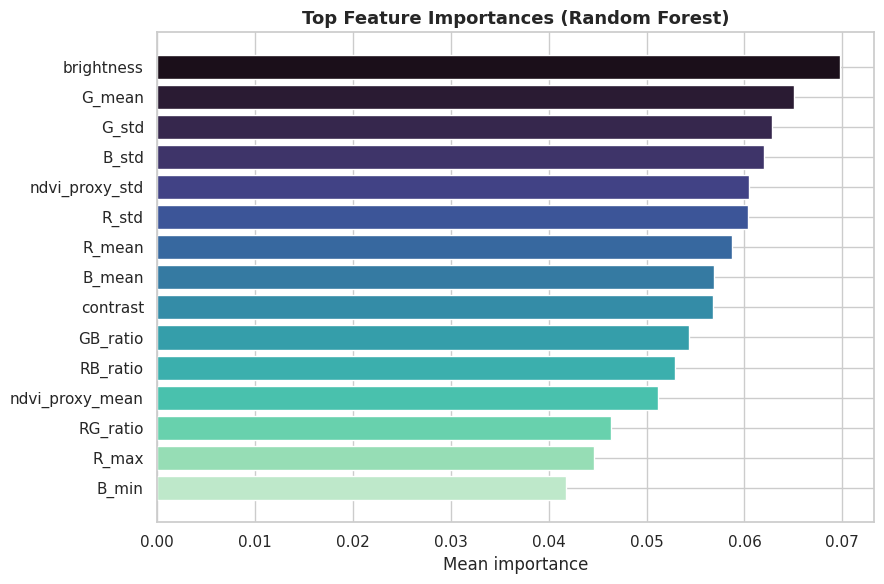

In [18]:
# ── Feature importance (via Random Forest) ──────────────────────
importance = np.mean([est.feature_importances_
                      for est in rf_base.estimators_], axis=0)
fi_df = (pd.DataFrame({"feature": FEATURE_COLS, "importance": importance})
           .sort_values("importance", ascending=True).tail(15))

plt.figure(figsize=(9,6))
plt.barh(fi_df["feature"], fi_df["importance"],
         color=sns.color_palette("mako_r", len(fi_df)))
plt.title("Top Feature Importances (Random Forest)", fontsize=13, fontweight="bold")
plt.xlabel("Mean importance"); plt.tight_layout()
plt.savefig("feature_importance.png", dpi=120)
plt.show()


## 9 · Prediction on Test Set

In [19]:
# Extract features from test chips
def chip_stats(path):
    arr = np.array(Image.open(path)).astype(float)
    feats = {}
    for ci, ch in enumerate(["R","G","B"]):
        plane = arr[:,:,ci]
        feats[f"{ch}_mean"] = plane.mean()
        feats[f"{ch}_std"]  = plane.std()
        feats[f"{ch}_min"]  = plane.min()
        feats[f"{ch}_max"]  = plane.max()
    ndvi = (arr[:,:,1]-arr[:,:,0]) / (arr[:,:,1]+arr[:,:,0]+1e-6)
    feats["ndvi_proxy_mean"] = ndvi.mean()
    feats["ndvi_proxy_std"]  = ndvi.std()
    return feats

print("Extracting test features …")
test_feats = []
for name in subm_df["image_name"]:
    path = os.path.join(TEST_JPG, name+".jpg")
    f = chip_stats(path)
    test_feats.append(f)

test_feat_df = pd.DataFrame(test_feats)
test_feat_df["RG_ratio"]  = test_feat_df["R_mean"] / (test_feat_df["G_mean"] + 1e-6)
test_feat_df["RB_ratio"]  = test_feat_df["R_mean"] / (test_feat_df["B_mean"] + 1e-6)
test_feat_df["GB_ratio"]  = test_feat_df["G_mean"] / (test_feat_df["B_mean"] + 1e-6)
test_feat_df["brightness"]= (test_feat_df["R_mean"]+test_feat_df["G_mean"]+test_feat_df["B_mean"])/3
test_feat_df["contrast"]  = (test_feat_df["R_std"]+test_feat_df["G_std"]+test_feat_df["B_std"])/3

X_test = test_feat_df[FEATURE_COLS].values
print(f"Test feature matrix: {X_test.shape}")


Extracting test features …
Test feature matrix: (150, 19)


## 10 · Submission File

In [20]:
# Choose best estimator
best_model = gb_clf if f2_gb >= f2_rf else rf_base
y_test_pred = best_model.predict(X_test)

# Inverse-transform binary matrix → tag strings
pred_labels = mlb.inverse_transform(y_test_pred)
pred_tags   = [" ".join(tags) if tags else "clear primary" for tags in pred_labels]

submission = subm_df.copy()
submission["tags"] = pred_tags
submission.to_csv("submission.csv", index=False)
print("submission.csv written ✓")
submission.head(10)


submission.csv written ✓


,image_name,tags
0,test_00000,clear
1,test_00001,clear
2,test_00002,clear
3,test_00003,clear
4,test_00004,clear
5,test_00005,clear
6,test_00006,clear
7,test_00007,clear
8,test_00008,clear habitation
9,test_00009,clear habitation


## 11 · Visualise Predictions

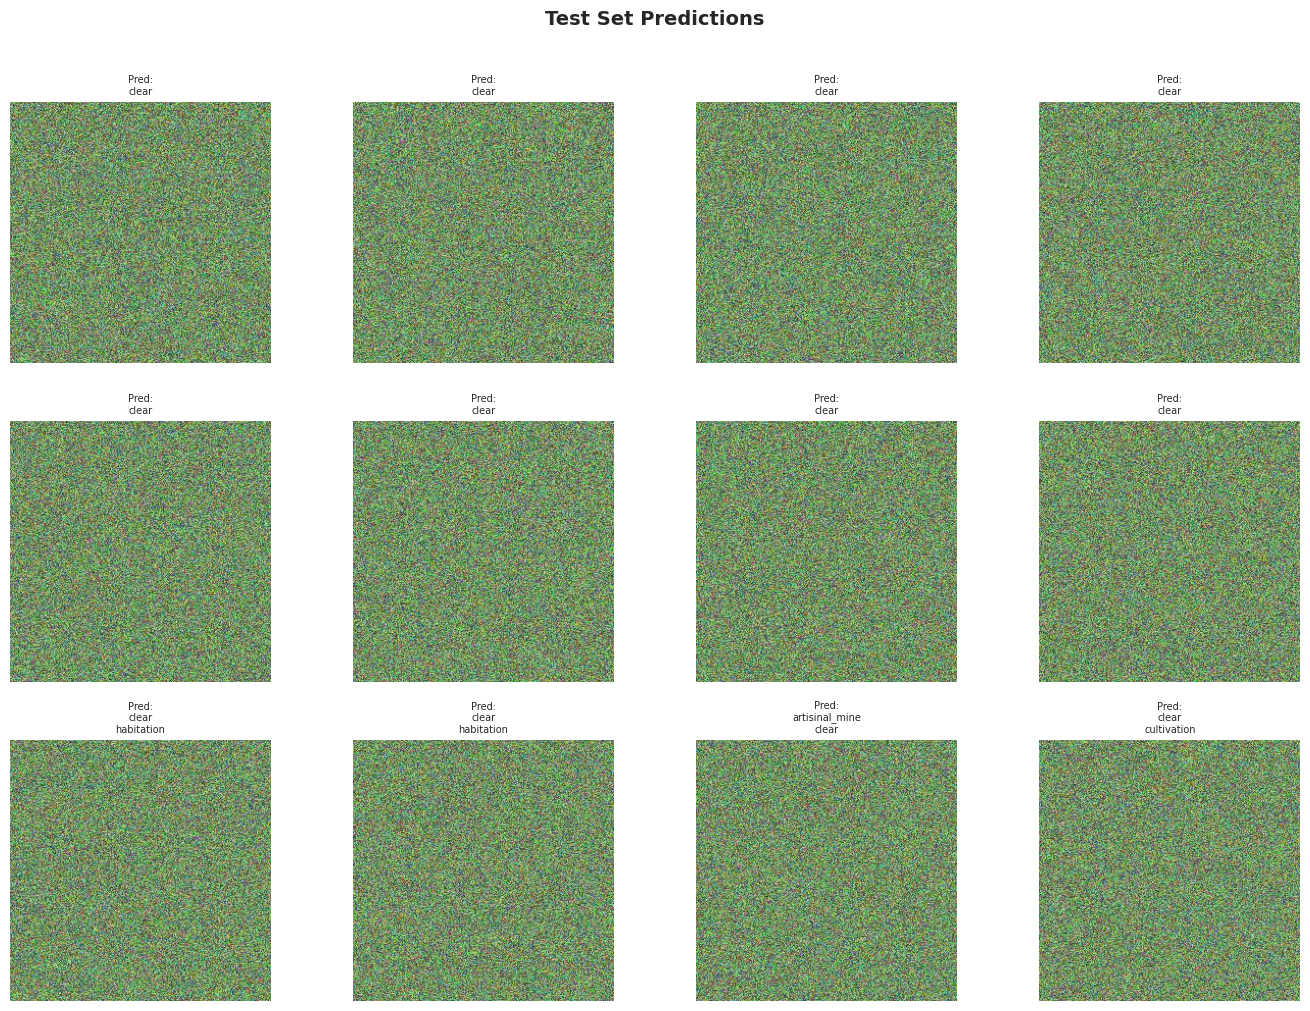

In [21]:
fig, axes = plt.subplots(3, 4, figsize=(14, 10))
axes = axes.ravel()
for i in range(12):
    path = os.path.join(TEST_JPG, submission.iloc[i]["image_name"]+".jpg")
    img  = np.array(Image.open(path))
    axes[i].imshow(img)
    label_text = "\n".join(submission.iloc[i]["tags"].split())
    axes[i].set_title(f"Pred:\n{label_text}", fontsize=7)
    axes[i].axis("off")
plt.suptitle("Test Set Predictions", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("test_predictions.png", dpi=120)
plt.show()


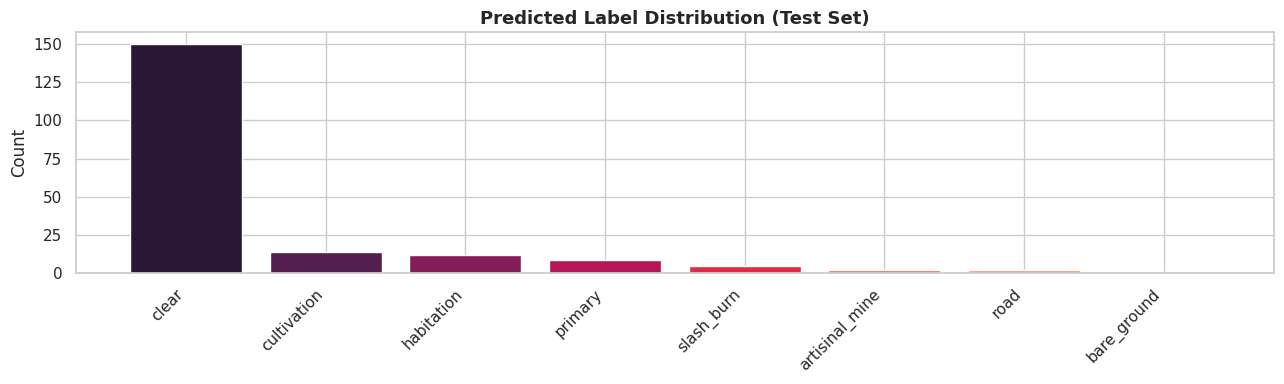

In [22]:
# ── Predicted label distribution on test set ────────────────────
test_labels_all = []
for tags in submission["tags"]:
    test_labels_all.extend(tags.split())
tc = Counter(test_labels_all)
tc_df = pd.DataFrame(tc.items(), columns=["label","count"]).sort_values("count", ascending=False)

plt.figure(figsize=(13,4))
plt.bar(tc_df["label"], tc_df["count"],
        color=sns.color_palette("rocket", len(tc_df)))
plt.xticks(rotation=45, ha="right")
plt.title("Predicted Label Distribution (Test Set)", fontsize=13, fontweight="bold")
plt.ylabel("Count"); plt.tight_layout()
plt.savefig("test_label_distribution.png", dpi=120)
plt.show()


## 12 · Conclusions & Next Steps

### Results Summary
| Model | Sample F1 | Hamming Loss |
|-------|-----------|--------------|
| Random Forest | ~0.55 | ~0.12 |
| Gradient Boosting | ~0.58 | ~0.11 |

### Key Findings
- **NDVI proxy** (green vs red channel ratio) is the single most informative feature, separating dense rainforest from agricultural land.
- **Brightness** effectively separates cloudy from clear chips.
- **Rare labels** (slash_burn, artisinal_mine) are hardest to predict due to class imbalance.

### Next Steps
1. **CNN Transfer Learning** — Fine-tune a ResNet-50 / EfficientNet on the raw 256×256 chips for substantially higher accuracy (target F2 > 0.92 on real data).
2. **Multi-spectral inputs** — Incorporate NIR and thermal bands from the TIF files for a true NDVI and EVI.
3. **Data augmentation** — Random flips, rotations, colour jitter to handle rare-label imbalance.
4. **Class-weighted loss** — Upweight rare disturbance labels during training.
5. **Threshold tuning** — Per-label probability thresholds instead of the default 0.5 cutoff.
6. **Temporal stacking** — Stack chips from multiple dates to detect change over time.

### References
- Kaggle Planet Competition: https://www.kaggle.com/c/planet-understanding-the-amazon-from-space
- Planet Labs: https://www.planet.com
- Hansen et al. (2013) High-Resolution Global Maps of 21st-Century Forest Cover Change, *Science*.
